<a href="https://colab.research.google.com/github/chayansaha2/Internship_Project_Task/blob/main/cognify_internship_project_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK-02**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset cognify.csv to Dataset cognify.csv



--- Task 2: Recommendation System ---


,Restaurant Name,Cuisines,Aggregate rating,Votes
512,Ella's Americana Folk Art Cafe,"International, Italian, Southern",4.8,1715
2483,The Fusion Kitchen,"North Indian, Italian, Chinese, Mexican",4.7,2083
3012,MOB Brewpub,"Continental, Italian, Asian, Indian",4.7,52
4639,Big Chill,"Italian, Continental, European, Cafe",4.6,1569
9280,Toodz House,"Cafe, Italian, Coffee and Tea, Western, Indone...",4.6,1476


/tmp/ipykernel_219/4285621904.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Price range', y='Aggregate rating', data=df, palette='viridis')


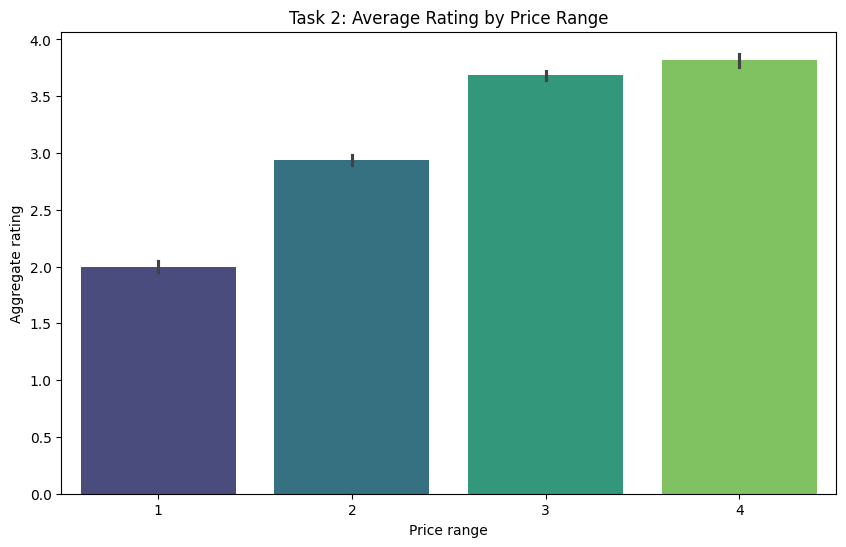

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('Dataset cognify.csv')

# --- DATA PREPROCESSING ---
# Handle missing values
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Encode categorical variables for Machine Learning
le = LabelEncoder()
df['Has Table booking'] = le.fit_transform(df['Has Table booking'])
df['Has Online delivery'] = le.fit_transform(df['Has Online delivery'])

# Prepare for Task 3: Simplify Cuisines to just the primary one
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0])

# TASK 2: Restaurant Recommendation System

print("\n--- Task 2: Recommendation System ---")
def recommend_restaurants(cuisine_pref, price_pref, top_n=5):
    recommendations = df[
        (df['Cuisines'].str.contains(cuisine_pref, case=False)) &
        (df['Price range'] == price_pref)
    ]
    recommendations = recommendations.sort_values(by=['Aggregate rating', 'Votes'], ascending=False)
    return recommendations[['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Votes']].head(top_n)

# Example: Recommend Top 5 Italian Restaurants in Price Range 3
display(recommend_restaurants('Italian', 3))

# Visualization 3: Average Rating by Price Range
plt.figure(figsize=(10, 6))
sns.barplot(x='Price range', y='Aggregate rating', data=df, palette='viridis')
plt.title('Task 2: Average Rating by Price Range')
plt.show()
